Two questions for the presentation: 
1. What can we learn about social data science from a merged network of all the different responses?
2. What can we learn from individual networks that is not apparent from the merged response? 

You only need to submit a group presentation and the code. However! This time around, each person in the group must put their name to a specific claim for question 2. Only person will deliver the presentation, but there should be a slide (or n slides) that state a single claim per person. For example:
- "Alice discovered that only one network linked 'community' and 'class' ". 
- "Bob discovered that networks which mentioned 'community' were the densest".

These claims need not be profound, only defensible and where appropriate falsifiable.

In [72]:
import networkx as nx 
import pandas as pd 
from pathlib import Path

# setting the directory path
data_dir = Path('/Users/howardleong/Desktop/academic/Fundamentals of Social Data Science in Python/Week 2/Network Canvas Export Tables')  

# function to load csv file
def load_csv_files(pattern):
    dfs = []
    for file in data_dir.glob(pattern):
        df = pd.read_csv(file)
        df['source_file'] = file.name
        dfs.append(df)
    
    if dfs:
        return pd.concat(dfs, ignore_index=True)
        
    return None

# Load different types of files
attr_df = load_csv_files("*_attributeList_concept.csv")
ego_df = load_csv_files("*_ego.csv")
edge_df = load_csv_files("*_edgeList_relate.csv")


In [73]:
# get the SessionID from attriubute file source_file column
attr_df['SessionID'] = attr_df['source_file'].str.extract(r'Anonymous Participant_([\w]+)_attributeList_concept\.csv')
ego_df['SessionID'] = ego_df['source_file'].str.extract(r'Anonymous Participant_([\w]+)_ego\.csv')

# merge attribute file with ego file based on SessionID
df_alter = pd.merge(attr_df, ego_df, on='SessionID', suffixes=('_attr', '_ego'))
df_alter["name"].value_counts()

name
AI                 15
technology         11
empirical data     10
ethics             10
analysis           10
knowledge           9
context             8
theory              8
community           8
social networks     7
change              7
optimisation        6
perspective         6
truth               6
macro-micro         5
inequality          5
identity            5
culture             5
structure           5
power               4
development         4
policy              4
progress            4
social norms        3
justice             2
design              2
collective          2
user experience     2
class               2
privacy             2
race-ethnicity      2
art                 1
freedom             1
music               1
personal            1
history             1
individual          1
gender              1
Name: count, dtype: int64

In [74]:
# build a dictionary {"sessionID": file_path}
edge_list = []
for i in data_dir.glob("*ego.csv"):
    x = i.name.split("_")[:-1]
    x.append("edgeList_relate.csv")
    edge_path = Path(data_dir / "_".join(x))
    key = i.name.split("_")[1]
    
    if edge_path.exists():
        edge_list.append(
            {"key": key,
             "path": edge_path
             })
    else:
        raise Exception("Warning: The edge path file does not exist.") 


# read the edge files and build graphs
edgelist_dfs = []
for edge_file in edge_list:
    edge_df = pd.read_csv(edge_file["path"])
    edges = zip(edge_df["networkCanvasSourceUUID"].to_list(),edge_df["networkCanvasTargetUUID"].to_list())
    edges = list(edges)
    G = nx.Graph(edges) # put it into a networkx graph

    # Find the connected components, sort them by size (largest first)
    ccs = sorted(list(nx.connected_components(G)), key=len, reverse=True)

    # Get the largest component (or components, in case of a tie)
    giant_component = ccs[0]
    if len(ccs) > 1:
        for i in ccs[1:]:
            if len(i) == len(ccs[0]):
                giant_component.extend(i)

    # Create a dataframe for the nodes in the giant component
    df_temp = pd.DataFrame(giant_component, columns=["networkCanvasUUID"])
    df_temp["networkCanvasSessionID"] = edge_file["key"]
    df_temp["in_gcc"] = 1 # tag as in gcc 
    edgelist_dfs.append(df_temp)

# Combine all the dataframes and merge with df_alters
df_edgelist_gcc = pd.concat(edgelist_dfs) 
df_alter = df_alter.merge(df_edgelist_gcc, on=["networkCanvasSessionID","networkCanvasUUID"], how="left")

# Where we didn't get a value from the merge, that node was not in the giant component for that ego
df_alter.fillna({"in_gcc":0}, inplace = True)
display(df_alter)

,nodeID,networkCanvasEgoUUID_attr,networkCanvasUUID,name,user_layout_x,user_layout_y,user_layout_screenSpaceX,user_layout_screenSpaceY,source_file_attr,SessionID,...,networkCanvasSessionID,networkCanvasProtocolName,sessionStart,sessionFinish,sessionExported,APP_VERSION,COMMIT_HASH,secret_word,source_file_ego,in_gcc
0,1,7be8425e-a3ba-4d37-a9c9-14ea20de21cb,ZuysvCGddv,AI,0.677439,0.639616,1300.68,389.21,Anonymous Participant_cmh1ulurw000lsa2750fqbpi...,cmh1ulurw000lsa2750fqbpip,...,cmh1ulurw000lsa2750fqbpip,FSDS_ConceptMap_v01.netcanvas,2025-10-22T10:26:24.140Z,2025-10-22T10:30:47.190Z,2025-10-24T12:37:16.921Z,v3.0.0,Unknown commit hash,falafel,Anonymous Participant_cmh1ulurw000lsa2750fqbpi...,1.0
1,2,7be8425e-a3ba-4d37-a9c9-14ea20de21cb,zfLP4gy4BA,analysis,0.551915,0.381659,1059.68,667.81,Anonymous Participant_cmh1ulurw000lsa2750fqbpi...,cmh1ulurw000lsa2750fqbpip,...,cmh1ulurw000lsa2750fqbpip,FSDS_ConceptMap_v01.netcanvas,2025-10-22T10:26:24.140Z,2025-10-22T10:30:47.190Z,2025-10-24T12:37:16.921Z,v3.0.0,Unknown commit hash,falafel,Anonymous Participant_cmh1ulurw000lsa2750fqbpi...,1.0
2,3,7be8425e-a3ba-4d37-a9c9-14ea20de21cb,kojNKla2jv,context,0.481428,0.731364,924.34,290.13,Anonymous Participant_cmh1ulurw000lsa2750fqbpi...,cmh1ulurw000lsa2750fqbpip,...,cmh1ulurw000lsa2750fqbpip,FSDS_ConceptMap_v01.netcanvas,2025-10-22T10:26:24.140Z,2025-10-22T10:30:47.190Z,2025-10-24T12:37:16.921Z,v3.0.0,Unknown commit hash,falafel,Anonymous Participant_cmh1ulurw000lsa2750fqbpi...,1.0
3,4,7be8425e-a3ba-4d37-a9c9-14ea20de21cb,RtJiUdZJi6,empirical data,0.481428,0.489363,924.34,551.49,Anonymous Participant_cmh1ulurw000lsa2750fqbpi...,cmh1ulurw000lsa2750fqbpip,...,cmh1ulurw000lsa2750fqbpip,FSDS_ConceptMap_v01.netcanvas,2025-10-22T10:26:24.140Z,2025-10-22T10:30:47.190Z,2025-10-24T12:37:16.921Z,v3.0.0,Unknown commit hash,falafel,Anonymous Participant_cmh1ulurw000lsa2750fqbpi...,1.0
4,5,7be8425e-a3ba-4d37-a9c9-14ea20de21cb,KaMS6JqOHq,ethics,0.603090,0.515956,1157.93,522.77,Anonymous Participant_cmh1ulurw000lsa2750fqbpi...,cmh1ulurw000lsa2750fqbpip,...,cmh1ulurw000lsa2750fqbpip,FSDS_ConceptMap_v01.netcanvas,2025-10-22T10:26:24.140Z,2025-10-22T10:30:47.190Z,2025-10-24T12:37:16.921Z,v3.0.0,Unknown commit hash,falafel,Anonymous Participant_cmh1ulurw000lsa2750fqbpi...,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,8,7be8425e-a3ba-4d37-a9c9-14ea20de21cb,ndsons1JEx,social networks,0.673568,0.580938,1293.25,452.59,Anonymous Participant_cmh4n1pe9003gsa27d06mabf...,cmh4n1pe9003gsa27d06mabf0,...,cmh4n1pe9003gsa27d06mabf0,FSDS_ConceptMap_v01.netcanvas,2025-10-24T09:18:05.257Z,2025-10-24T09:22:43.127Z,2025-10-24T12:35:48.005Z,v3.0.0,Unknown commit hash,cookie,Anonymous Participant_cmh4n1pe9003gsa27d06mabf...,0.0
182,9,7be8425e-a3ba-4d37-a9c9-14ea20de21cb,uBiRoP3A3s,progress,0.379092,0.532845,727.86,504.53,Anonymous Participant_cmh4n1pe9003gsa27d06mabf...,cmh4n1pe9003gsa27d06mabf0,...,cmh4n1pe9003gsa27d06mabf0,FSDS_ConceptMap_v01.netcanvas,2025-10-24T09:18:05.257Z,2025-10-24T09:22:43.127Z,2025-10-24T12:35:48.005Z,v3.0.0,Unknown commit hash,cookie,Anonymous Participant_cmh4n1pe9003gsa27d06mabf...,0.0
183,10,7be8425e-a3ba-4d37-a9c9-14ea20de21cb,qlYrXp5pWY,power,0.524712,0.682991,1007.45,342.37,Anonymous Participant_cmh4n1pe9003gsa27d06mabf...,cmh4n1pe9003gsa27d06mabf0,...,cmh4n1pe9003gsa27d06mabf0,FSDS_ConceptMap_v01.netcanvas,2025-10-24T09:18:05.257Z,2025-10-24T09:22:43.127Z,2025-10-24T12:35:48.005Z,v3.0.0,Unknown commit hash,cookie,Anonymous Participant_cmh4n1pe9003gsa27d06mabf...,1.0
184,11,7be8425e-a3ba-4d37-a9c9-14ea20de21cb,FXe1ucLJSr,perspective,0.434913,0.406158,835.03,641.35,Anonymous Participant_cmh4n1pe9003gsa27d06mabf...,cmh4n1pe9003gsa27d06mabf0,...,cmh4n1pe9003gsa27d06mabf0,FSDS_ConceptMap_v01.netcanvas,2025-10-24T09:18:05.257Z,2025-10-24T09:22:43.127Z,2025-10-24T12:35:48.005Z,v3.0.0,Unknown commit hash,cookie,Anonymous Participant_cmh4n1pe9003gsa27d06mabf...,0.0


In [75]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean
from collections import defaultdict

# Get unique alter names
unique_alters = df_alter['name'].unique()

# Dictionary to store distances for each pair across sessions
pair_distances = defaultdict(list)

# Calculate distances for each session
for session_id in df_alter['SessionID'].unique():
    df_temp = df_alter[df_alter['SessionID'] == session_id]
    
    for i in df_temp['name'].unique():
        for j in df_temp['name'].unique():
            if i != j:
                vec_i = df_temp[df_temp['name'] == i][['user_layout_x', 'user_layout_y']].values.flatten()
                vec_j = df_temp[df_temp['name'] == j][['user_layout_x', 'user_layout_y']].values.flatten()
                
                # Only calculate if both vectors exist and are not empty
                if len(vec_i) > 0 and len(vec_j) > 0:
                    dist = euclidean(vec_i, vec_j)
                    pair_distances[(i, j)].append(dist)

# Create dataframe and populate with averaged distances
df_relative = pd.DataFrame(index=unique_alters, columns=unique_alters)

for (i, j), distances in pair_distances.items():
    df_relative.loc[i, j] = np.mean(distances)

# Optional: fill diagonal with 0 (distance from alter to itself)
np.fill_diagonal(df_relative.values, 0)

display(df_relative)


,AI,analysis,context,empirical data,ethics,optimisation,personal,progress,social networks,change,...,structure,development,art,design,justice,music,collective,history,individual,user experience
AI,0,0.195728,0.244217,0.213134,0.169079,0.296722,0.279658,0.169614,0.279036,0.185773,...,0.315211,0.171462,0.22856,0.182579,0.153865,0.189111,0.097076,0.181882,0.310273,0.445278
analysis,0.195728,0,0.257675,0.16335,0.207046,0.231789,0.229443,0.204101,0.44796,0.255441,...,0.336052,0.253041,NaN,NaN,0.14683,NaN,0.172987,NaN,0.103967,0.281567
context,0.244217,0.257675,0,0.173951,0.238654,0.278605,0.184965,0.290917,0.238062,0.276951,...,0.276796,0.261258,NaN,0.094067,NaN,NaN,0.245827,0.083406,0.140799,0.230794
empirical data,0.213134,0.16335,0.173951,0,0.204641,0.279805,0.10198,0.185259,0.265687,0.235694,...,0.278027,0.172479,NaN,NaN,0.07952,NaN,0.164283,0.188604,NaN,NaN
ethics,0.169079,0.207046,0.238654,0.204641,0,0.302118,0.199276,0.215418,0.34083,0.112162,...,0.180557,0.333262,NaN,NaN,0.207121,NaN,0.080635,0.232886,0.243435,0.386417
optimisation,0.296722,0.231789,0.278605,0.279805,0.302118,0,0.412113,0.381693,0.292282,0.219374,...,0.238139,0.456117,NaN,0.222149,NaN,NaN,0.326843,NaN,NaN,0.091122
personal,0.279658,0.229443,0.184965,0.10198,0.199276,0.412113,0,0.322831,0.14113,0.326896,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
progress,0.169614,0.204101,0.290917,0.185259,0.215418,0.381693,0.322831,0,0.31944,0.164063,...,NaN,0.086198,NaN,0.177516,NaN,NaN,NaN,NaN,NaN,0.337775
social networks,0.279036,0.44796,0.238062,0.265687,0.34083,0.292282,0.14113,0.31944,0,0.391351,...,0.147534,0.270323,NaN,0.191592,NaN,NaN,0.53027,NaN,NaN,0.272691
change,0.185773,0.255441,0.276951,0.235694,0.112162,0.219374,0.326896,0.164063,0.391351,0,...,0.394072,0.334788,NaN,NaN,0.222783,NaN,0.229925,NaN,NaN,NaN


- Correlation
• Jaccard
• Euclidean distance
• Cosine distance
• Distinguishing parametric and non-parametric analysis

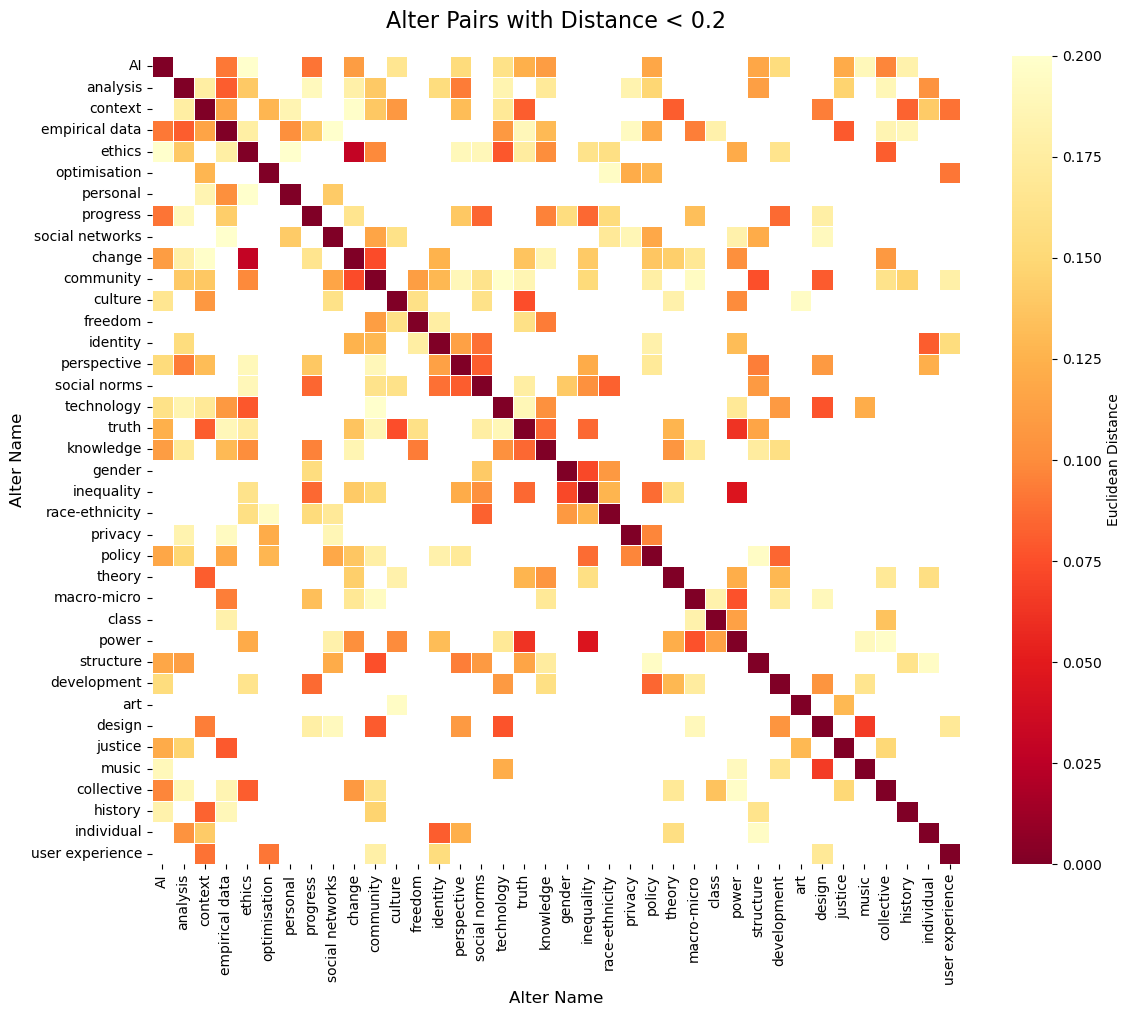

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a mask for values >= 0.2
mask = df_relative.astype(float) >= 0.2

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_relative.astype(float), 
            annot=False,  # Don't show values
            cmap='YlOrRd_r',
            mask=mask,  # Hide values >= 0.2
            cbar_kws={'label': 'Euclidean Distance'},
            linewidths=0.5,
            square=True,
            vmin=0,
            vmax=0.2)  # Set color scale to 0-0.2 range

plt.title('Alter Pairs with Distance < 0.2', fontsize=16, pad=20)
plt.xlabel('Alter Name', fontsize=12)
plt.ylabel('Alter Name', fontsize=12)
plt.tight_layout()
plt.show()

In [82]:
# aggregate the number of edges between each pair of alters across all sessions
edge_counts = defaultdict(int)
for session_id in df_alter['SessionID'].unique():
    df_temp = df_alter[df_alter['SessionID'] == session_id]
    alters_in_session = df_temp['name'].unique()
    
    for i in alters_in_session:
        for j in alters_in_session:
            if i != j:
                edge_counts[(i, j)] += 1

# create a DataFrame to represent the aggregated edge counts
df_edge_counts = pd.DataFrame(index=unique_alters, columns=unique_alters).fillna(0)
for (i, j), count in edge_counts.items():
    df_edge_counts.loc[i, j] = count
display(df_edge_counts)


/var/folders/fs/_sxx6rsx057_6zchlyc3dgp40000gn/T/ipykernel_42948/1881282393.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_edge_counts = pd.DataFrame(index=unique_alters, columns=unique_alters).fillna(0)


,AI,analysis,context,empirical data,ethics,optimisation,personal,progress,social networks,change,...,structure,development,art,design,justice,music,collective,history,individual,user experience
AI,0,9,7,9,10,5,1,4,5,5,...,4,4,1,2,2,1,1,1,1,2
analysis,9,0,5,7,7,3,1,2,2,6,...,2,1,0,0,1,0,2,0,1,1
context,7,5,0,4,3,4,1,2,4,3,...,3,1,0,1,0,0,1,1,1,2
empirical data,9,7,4,0,8,4,1,3,4,5,...,3,2,0,0,1,0,2,1,0,0
ethics,10,7,3,8,0,3,1,3,3,4,...,3,3,0,0,1,0,1,1,1,1
optimisation,5,3,4,4,3,0,1,3,5,2,...,1,1,0,1,0,0,1,0,0,1
personal,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
progress,4,2,2,3,3,3,1,0,3,1,...,0,1,0,1,0,0,0,0,0,1
social networks,5,2,4,4,3,5,1,3,0,3,...,2,1,0,1,0,0,1,0,0,1
change,5,6,3,5,4,2,1,1,3,0,...,2,1,0,0,1,0,2,0,0,0


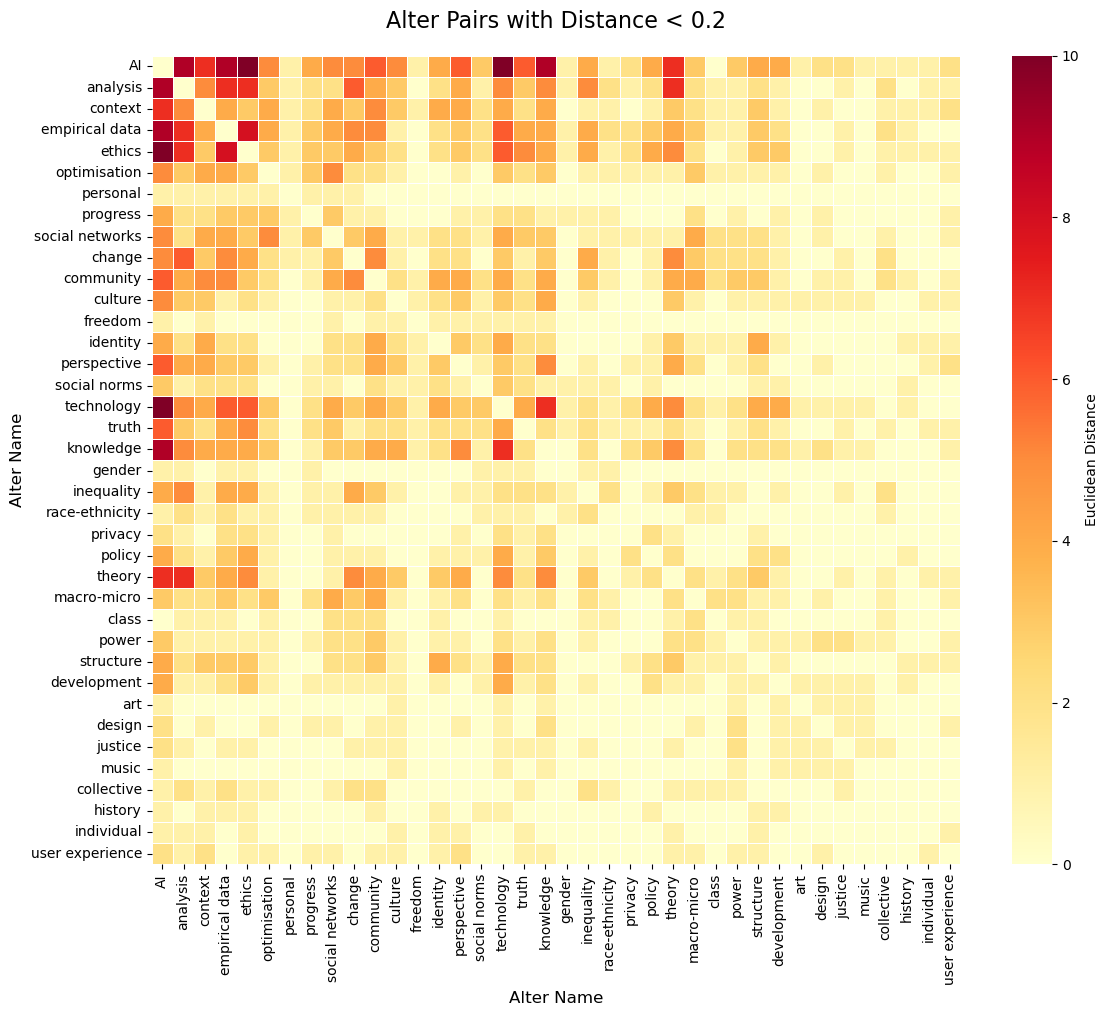

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_edge_counts.astype(float), 
            annot=False,
            cmap='YlOrRd',
            cbar_kws={'label': 'Euclidean Distance'},
            linewidths=0.5,
            square=True)

plt.title('Alter Pairs with Distance < 0.2', fontsize=16, pad=20)
plt.xlabel('Alter Name', fontsize=12)
plt.ylabel('Alter Name', fontsize=12)
plt.tight_layout()
plt.show()